# 033_bis — Signal Evaluation against ground truth (`data/test/annotations/`)

Same signal construction as `033_signal_evaluation.ipynb` (raw delta, structural delta, NLL `|z|`, per architecture and loss variant) and the same unsupervised stroke-coherence axis (`scripts.stroke_stats`), but scored against a **real, hand-drawn ground-truth mask** instead of the cross-modal pseudo ground truth (`scripts.pseudo_mask`) — no longer needed now that hand-drawn masks exist.

`evaluation.md` §3 explains why the main corpus (`data/ir`/`data/rgb`, scored in `033`) isn't a fair test of hidden-detail detection — the only systematic RGB/IR difference there is paint-stroke thickness, not documented hidden content. `data/test/annotations/` fixes that: each `<stem>_Map.png` there marks exactly where a specific, identified cause (underdrawing, pentimento, reused support) is known to be, drawn by hand rather than inferred from the images. Only the images with a mask (`GT01`, `GT02`, `GT03`) are scored here — `data/test/` also holds other images added purely for visual/qualitative inspection (`051`/`060`/`062`), not part of this detection ranking.

- **Detection** (`scripts.detection`) — real ground-truth mask, AUROC / average precision / lift.
- **Stroke coherence** (`scripts.stroke_stats`) — unchanged, fully unsupervised.

Read like the previous pseudo-mask version: `auroc` primary ranking, `lift` relative to chance, agreement between the two axes in §6 is the real result. Unlike the pseudo-mask, this reference doesn't share its construction with the structural delta, so §4 on its own is now a fair comparison across signal *types*, not just within one — §6 remains useful as independent corroboration, not as a bias correction.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from scipy.stats import spearmanr

from scripts.calibration import learned_zscore
from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import compute_local_stats, compute_ssim_components
from scripts.detection import rank_signals
from scripts.stroke_stats import stroke_coherence
from scripts.trainer import load_model
from scripts.trainer_nll import load_model_nll
from scripts.visualization_nll import plot_signal_comparison

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Ground-truth images

Only `(rgb, ir)` pairs with a matching `data/test/annotations/<stem>_Map.png` are scored — currently `GT01`, `GT02`, `GT03`. None of `data/test/` is read by `020`/`021`/`022`, so nothing here was seen in training regardless of which architecture's checkpoint is loaded below.

In [3]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"
ANNOTATIONS_DIR = project_root / "data" / "test" / "annotations"

# Only images with a real ground-truth mask are scored here — data/test/
# also holds other images (bridge, case, face, green, modern, modern2,
# total) added purely for visual/qualitative inspection in 051/060/062,
# which have no mask and are not part of this detection-ranking notebook.
mask_paths = (
    sorted(ANNOTATIONS_DIR.glob("*_Map.png")) if ANNOTATIONS_DIR.exists() else []
)
eval_pairs = []
for mask_path in mask_paths:
    stem = mask_path.name.removesuffix("_Map.png")
    rgb_path, ir_path = TEST_RGB_DIR / f"{stem}.jpg", TEST_IR_DIR / f"{stem}.jpg"
    if rgb_path.exists() and ir_path.exists():
        eval_pairs.append((rgb_path, ir_path))
    else:
        print(f"[skip] {stem}: mask found but rgb/ir pair missing")

print(f"Ground-truth images: {len(eval_pairs)} | {[p.stem for p, _ in eval_pairs]}")

if len(eval_pairs) < 2:
    raise RuntimeError(
        "Need at least 2 ground-truth images for the ranking's std and §6's rank "
        "correlation to mean anything. Add masks to data/test/annotations/."
    )

Ground-truth images: 3 | ['GT01', 'GT02', 'GT03']


## 2. Ground-truth mask

White = hidden-detail area (underdrawing / pentimento / reused support, per the image's known cause), black = everything else — hand-drawn, thresholded at the midpoint of the PNG's anti-aliased edges. Shown here for the first ground-truth image.

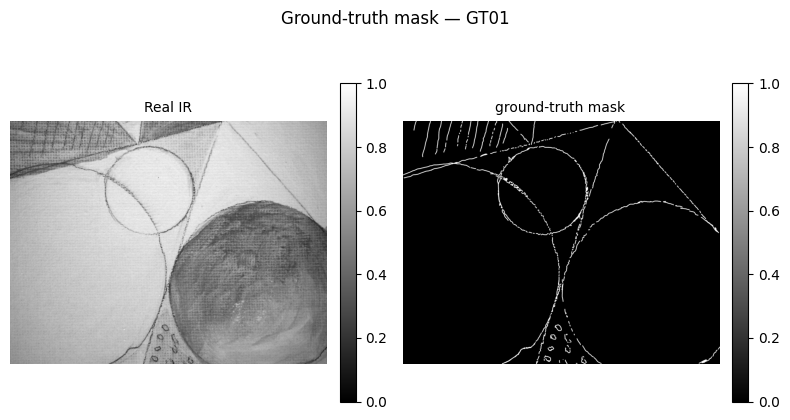

In [4]:
def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


MASK_THRESHOLD = 127  # midpoint threshold for the mask's anti-aliased edges


def load_mask(stem: str) -> np.ndarray:
    mask_path = ANNOTATIONS_DIR / f"{stem}_Map.png"
    return np.array(Image.open(mask_path).convert("L")) > MASK_THRESHOLD


rgb_demo, ir_demo = load_pair(*eval_pairs[0])
mask_demo = load_mask(eval_pairs[0][0].stem)

fig = plot_signal_comparison(
    ir_demo,
    {"ground-truth mask": mask_demo.astype(float)},
    title=f"Ground-truth mask — {eval_pairs[0][0].stem}",
    vrange=(0.0, 1.0),
)
plt.show()

## 3. Candidate signals, per model

Identical construction to `033` §3:

- deterministic architectures → raw delta `|IR - pred|` and structural delta `1 - structure`;
- NLL architectures, both loss variants → raw delta `|IR - mu|` and `|z| = |(IR - mu) / sigma|`.

Images here are full paintings of varying size, not fixed-size training patches, so each is padded to `settings.PATCH_MULTIPLE` and predicted in one shot (same pattern as `050`/`051`/`060`), rather than run through `build_dataset`.

In [5]:
# Every architecture with a checkpoint on disk is scored; missing ones are
# reported and skipped, so this runs against whatever has been trained so far.
DET_ARCHS = [
    "unet",
    "resunet",
    "attention_unet",
    "efficientnet_unet",
    "unet_v2",
    "unet_restormer",
]
NLL_ARCHS = ["unet_nll", "resunet_nll", "attention_unet_nll", "efficientnet_unet_nll"]
BETA_MODEL_DIR = settings.MODELS_DIR / "nll_beta"
BETA = 0.5

det_models = {}
for arch in DET_ARCHS:
    try:
        det_models[arch] = load_model(arch, model_dir=settings.MODELS_DIR)
    except (FileNotFoundError, OSError) as exc:
        print(f"[skip] {exc}")

nll_models = {}
for arch in NLL_ARCHS:
    for variant, model_dir in (
        ("gaussian", settings.MODELS_DIR),
        ("beta", BETA_MODEL_DIR),
    ):
        loss_name = "gaussian_nll" if variant == "gaussian" else "beta_nll"
        try:
            nll_models[f"{arch} ({variant})"] = load_model_nll(
                arch, model_dir=model_dir, loss_name=loss_name, beta=BETA
            )
        except (FileNotFoundError, OSError) as exc:
            print(f"[skip] {exc}")

n_signals = 2 * (len(det_models) + len(nll_models))
print(f"\nLoaded {len(det_models)} deterministic, {len(nll_models)} NLL models")
print(f"-> {n_signals} candidate signals per image")

# Fail here rather than four cells downstream: below three signals the ranking
# has nothing to rank and §6's rank correlation is trivially +/-1, which reads
# like a result but is an artefact of the sample size.
if n_signals < 3:
    raise RuntimeError(
        f"Only {n_signals} candidate signals available — at least 3 are needed "
        "for the ranking and the rank correlation to mean anything. Train the "
        "missing architectures (020/021/022) or point MODELS_DIR at a tree that "
        "holds their checkpoints."
    )

2026-08-20 17:27:16.936343: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-20 17:27:16.936358: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-20 17:27:16.936362: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-20 17:27:16.936374: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-20 17:27:16.936382: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Loaded 6 deterministic, 8 NLL models
-> 28 candidate signals per image


In [6]:
def structural_delta(ir, pred):
    """``1 - local SSIM structure`` between the real and predicted IR."""
    stats = compute_local_stats(ir, pred)
    return 1.0 - compute_ssim_components(stats).structure


def signals_for(rgb: np.ndarray, ir: np.ndarray) -> dict[str, np.ndarray]:
    """Build every candidate magnitude map for one full-size (rgb, ir) pair."""
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = ir.shape
    batch = padded[tf.newaxis, ...]

    signals = {}
    for name, model in det_models.items():
        pred = model.predict(batch, verbose=0)[0, :h, :w, 0]
        signals[f"{name} delta"] = np.abs(ir - pred)
        signals[f"{name} structural"] = structural_delta(ir, pred)
    for name, model in nll_models.items():
        pred = model.predict(batch, verbose=0)[0, :h, :w, :]
        mu, sigma = pred[..., 0], np.exp(0.5 * pred[..., 1])
        signals[f"{name} delta"] = np.abs(ir - mu)
        signals[f"{name} |z|"] = np.abs(learned_zscore(ir, mu, sigma))
    return signals


auroc_rows: dict[str, list[float]] = {}
ap_rows: dict[str, list[float]] = {}
lift_rows: dict[str, list[float]] = {}
coherence_rows: dict[str, list[float]] = {}

for rgb_path, ir_path in eval_pairs:
    rgb, ir = load_pair(rgb_path, ir_path)
    mask = load_mask(rgb_path.stem)
    signals = signals_for(rgb, ir)

    for name, result in rank_signals(signals, mask).items():
        auroc_rows.setdefault(name, []).append(result.auroc)
        ap_rows.setdefault(name, []).append(result.average_precision)
        lift_rows.setdefault(name, []).append(result.lift)
    for name, signal in signals.items():
        coherence_rows.setdefault(name, []).append(stroke_coherence(signal).coherence)

    print(f"{rgb_path.stem}: {len(signals)} signals scored")

2026-08-20 17:27:25.210765: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


GT01: 28 signals scored


GT02: 28 signals scored


GT03: 28 signals scored


## 4. Detection ranking

`auroc` is prevalence-independent and is the primary ranking. `lift` is average precision relative to chance: how much better than random the top of the ranking is. `std` across images is the honest error bar — a difference smaller than it means nothing, and with only 3 ground-truth images this bar is wide.

Unlike the cross-modal pseudo-mask this replaces, the ground-truth mask doesn't share its construction with any candidate signal — a structural signal scoring well here is not scoring well *by construction*, so comparing signal types against each other on this axis alone is now sound (§5/§6 remain useful as independent corroboration, not as a bias correction).

In [7]:
def summarise(rows):
    return {name: (float(np.mean(v)), float(np.std(v))) for name, v in rows.items()}


auroc_mean = summarise(auroc_rows)
ap_mean = summarise(ap_rows)
lift_mean = summarise(lift_rows)
ranking = sorted(auroc_mean, key=lambda n: auroc_mean[n][0], reverse=True)

col_w = 40
print("signal".ljust(col_w) + "auroc".ljust(18) + "avg_prec".ljust(18) + "lift")
print("-" * (col_w + 54))
for name in ranking:
    a, a_sd = auroc_mean[name]
    p, _ = ap_mean[name]
    fold, _ = lift_mean[name]
    print(f"{name.ljust(col_w)}{a:.4f} ± {a_sd:.3f}   {p:.4f}            {fold:.2f}x")

signal                                  auroc             avg_prec          lift
----------------------------------------------------------------------------------------------
unet_v2 structural                      0.6762 ± 0.044   0.0461            2.68x
unet_restormer structural               0.6690 ± 0.037   0.0540            2.93x
resunet structural                      0.6664 ± 0.061   0.0536            2.87x
efficientnet_unet structural            0.6539 ± 0.055   0.0514            2.74x
attention_unet structural               0.6485 ± 0.050   0.0454            2.39x
unet structural                         0.6461 ± 0.038   0.0445            2.44x
unet_v2 delta                           0.6061 ± 0.092   0.0611            3.26x
attention_unet_nll (gaussian) |z|       0.6046 ± 0.082   0.1084            5.84x
resunet_nll (gaussian) |z|              0.5885 ± 0.128   0.0954            4.82x
attention_unet_nll (gaussian) delta     0.5831 ± 0.114   0.0674            3.45x
unet delta    

### Per-image breakdown

The mean/std above average over all ground-truth images, which can hide a
signal that performs very differently on one image than another — e.g. a
strong result on one image diluted by weaker results on the others
(`evaluation.md` §6, point 2). One column per image, same signal order as
the ranking above.

In [8]:
image_stems = [p.stem for p, _ in eval_pairs]
header_cols = "".join(stem.rjust(10) for stem in image_stems)

print("signal".ljust(col_w) + header_cols)
print("-" * (col_w + 10 * len(image_stems)))
for name in ranking:
    row = "".join(f"{v:.3f}".rjust(10) for v in auroc_rows[name])
    print(f"{name.ljust(col_w)}{row}")

signal                                        GT01      GT02      GT03
----------------------------------------------------------------------
unet_v2 structural                           0.727     0.620     0.681
unet_restormer structural                    0.718     0.628     0.661
resunet structural                           0.750     0.611     0.638
efficientnet_unet structural                 0.727     0.642     0.593
attention_unet structural                    0.719     0.620     0.607
unet structural                              0.688     0.597     0.653
unet_v2 delta                                0.716     0.490     0.612
attention_unet_nll (gaussian) |z|            0.721     0.547     0.545
resunet_nll (gaussian) |z|                   0.767     0.524     0.475
attention_unet_nll (gaussian) delta          0.743     0.515     0.491
unet delta                                   0.714     0.540     0.474
attention_unet delta                         0.732     0.502     0.493
resune

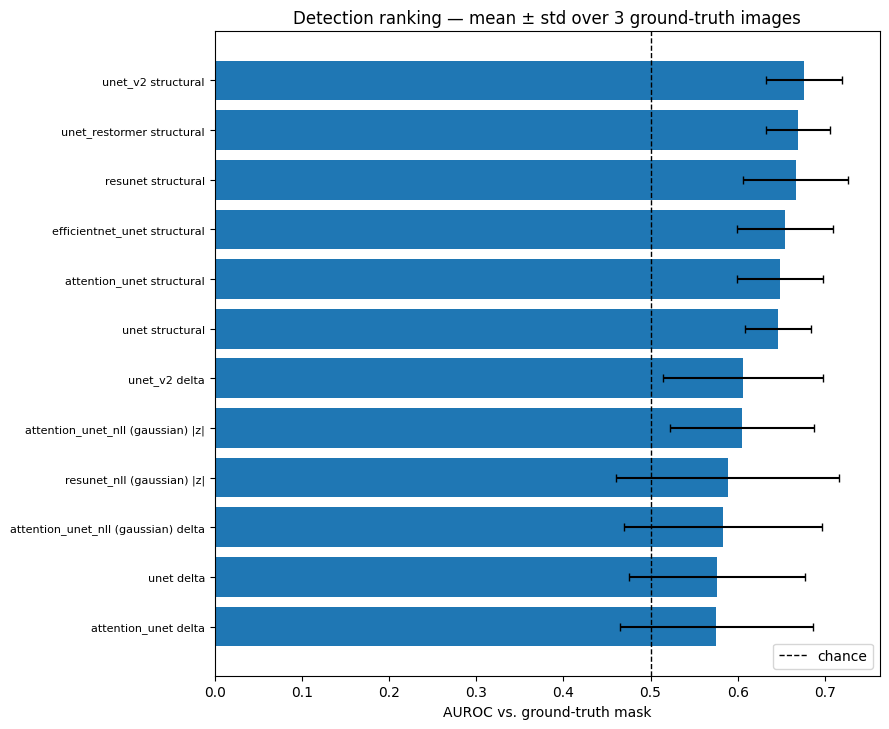

In [9]:
top = ranking[:12]
fig, ax = plt.subplots(figsize=(9, 0.45 * len(top) + 2))
y = np.arange(len(top))
ax.barh(
    y,
    [auroc_mean[n][0] for n in top],
    xerr=[auroc_mean[n][1] for n in top],
    capsize=3,
)
ax.axvline(0.5, color="k", ls="--", lw=1, label="chance")
ax.set_yticks(y)
ax.set_yticklabels(top, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("AUROC vs. ground-truth mask")
ax.set_title(
    f"Detection ranking — mean ± std over {len(eval_pairs)} ground-truth images"
)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Stroke coherence — the unsupervised axis

No reference at all: how much of each signal is oriented, line-like structure rather than isotropic noise. Read it with suspicion — a model with patch-stitching seams or `Conv2DTranspose` checkerboarding scores high while revealing nothing.

In [10]:
coherence_mean = summarise(coherence_rows)
by_coherence = sorted(coherence_mean, key=lambda n: coherence_mean[n][0], reverse=True)

print("signal".ljust(col_w) + "coherence")
print("-" * (col_w + 20))
for name in by_coherence:
    c, c_sd = coherence_mean[name]
    print(f"{name.ljust(col_w)}{c:.4f} ± {c_sd:.3f}")

signal                                  coherence
------------------------------------------------------------
unet_v2 structural                      0.4235 ± 0.110
unet_restormer structural               0.4149 ± 0.094
efficientnet_unet structural            0.3868 ± 0.095
attention_unet structural               0.3866 ± 0.079
unet structural                         0.3755 ± 0.076
resunet structural                      0.3710 ± 0.080
unet_nll (gaussian) delta               0.3467 ± 0.079
attention_unet_nll (gaussian) delta     0.3331 ± 0.061
unet delta                              0.3110 ± 0.078
unet_nll (gaussian) |z|                 0.3096 ± 0.087
unet_restormer delta                    0.3058 ± 0.073
attention_unet_nll (gaussian) |z|       0.3008 ± 0.085
attention_unet delta                    0.2952 ± 0.066
resunet delta                           0.2904 ± 0.073
unet_v2 delta                           0.2869 ± 0.065
unet_nll (beta) delta                   0.2839 ± 0.077
unet_nll 

## 6. Do the two axes agree?

They are wrong in different ways, so their agreement is the real result. A high rank correlation means both references point at the same signal and the conclusion is robust; a low one means at least one of them is measuring an artefact, and neither ranking should be trusted on its own.

Spearman(auroc, coherence) = 0.760 over 28 signals


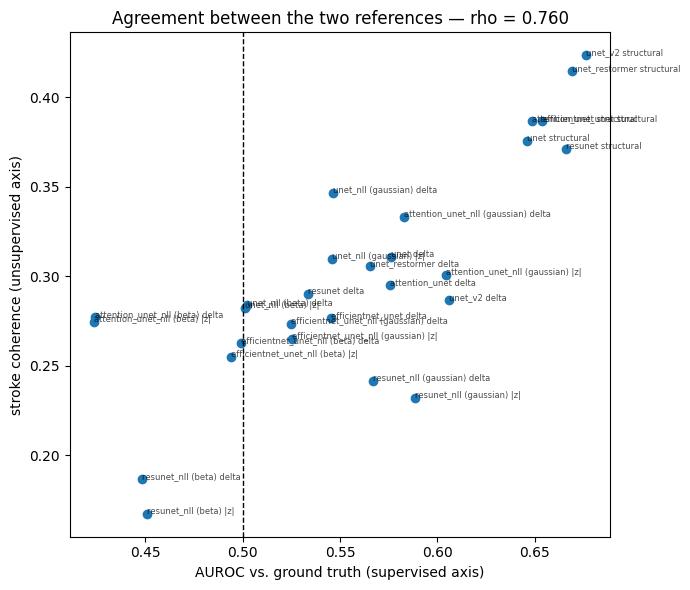

In [11]:
names = list(auroc_mean)
x = [auroc_mean[n][0] for n in names]
y = [coherence_mean[n][0] for n in names]
rho = spearmanr(x, y).statistic

print(f"Spearman(auroc, coherence) = {rho:.3f} over {len(names)} signals")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x, y)
for name, xi, yi in zip(names, x, y):
    ax.annotate(name, (xi, yi), fontsize=6, alpha=0.7)
ax.axvline(0.5, color="k", ls="--", lw=1)
ax.set_xlabel("AUROC vs. ground truth (supervised axis)")
ax.set_ylabel("stroke coherence (unsupervised axis)")
ax.set_title(f"Agreement between the two references — rho = {rho:.3f}")
plt.tight_layout()
plt.show()